# Module 2: Data Foundations, Preprocessing & Denoising

--- Step 1: Data Cleaning ---
Missing values found: 5
Missing values fixed via interpolation.


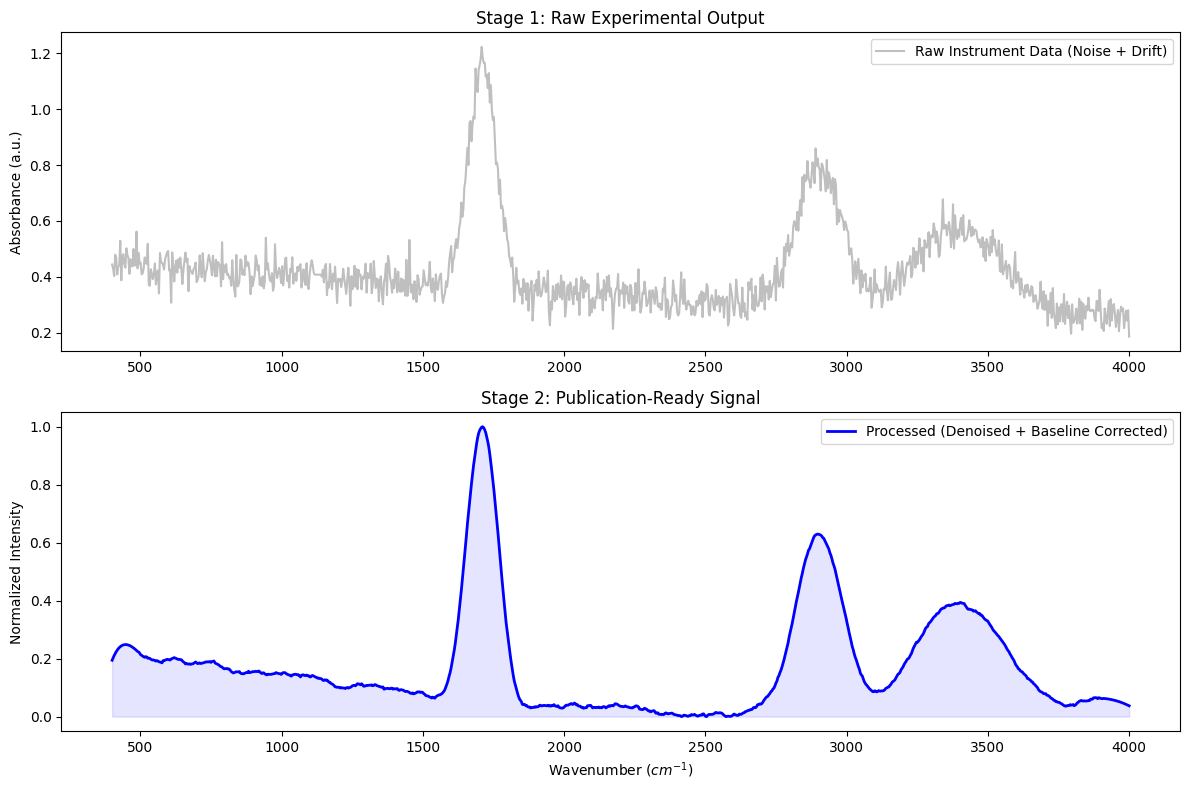


--- Summary ---
1. Missing values interpolated using Pandas.
2. Noise reduced using Savitzky-Golay (Window: 51).
3. Baseline drift removed via polynomial subtraction.


In [54]:
# Author: Llinersy Uranga Pina, LPPI - Cergy-Paris Université
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline

# 1. DATA GENERATION (Simulating "Raw" Experimental Data)
# We create a synthetic FTIR spectrum with noise and baseline drift.
def generate_raw_data(n_points=1000):
    x = np.linspace(400, 4000, n_points)  # Wavenumbers (cm-1)
    
    # Pure Signal: Three Gaussian peaks (Carbonyl, Hydroxyl, C-H)
    peaks = [
        (1710, 50, 0.8),  # (center, width, height)
        (2900, 80, 0.5),
        (3400, 150, 0.3)
    ]
    pure_signal = np.zeros_like(x)
    for center, width, height in peaks:
        pure_signal += height * np.exp(-((x - center)**2) / (2 * width**2))
    
    # Add "Instrumental" Noise
    noise = np.random.normal(0, 0.04, n_points)
    
    # Add "Baseline Drift" (Linear + Quadratic background)
    baseline = 0.5 - 0.0001 * x + 1e-8 * x**2
    
    # Combine to create Raw Data
    raw_signal = pure_signal + noise + baseline
    
    # Introduce "Human Error" (Some missing values)
    raw_signal[200:205] = np.nan 
    
    return x, raw_signal

# Generate our "Lab File"
wavenumbers, raw_absorbance = generate_raw_data()

# 2. DATA CLEANING (Handling Missing Values & Units)
# Creating a Pandas DataFrame to simulate an instrument export
df = pd.DataFrame({'Wavenumber': wavenumbers, 'Absorbance': raw_absorbance})

print("--- Step 1: Data Cleaning ---")
# Identify missing values
print(f"Missing values found: {df.isnull().sum()['Absorbance']}")

# Handle missing values: Linear Interpolation
df['Absorbance'] = df['Absorbance'].interpolate(method='linear')
print("Missing values fixed via interpolation.")

# 3. SIGNAL DENOISING (Savitzky-Golay)
# This filter fits a local polynomial to smooth noise without crushing peaks.
window_size = 51  # Must be odd
poly_order = 3
df['Smoothed'] = savgol_filter(df['Absorbance'], window_size, poly_order)

# 4. BASELINE CORRECTION (Rubberband/Spline Method)
# We estimate the background by looking at the "floor" of the signal
def baseline_correction(y, x):
    # Simplified approach: fit a low-order polynomial to the global minima
    # In a real lab, you'd use ALS (Asymmetric Least Squares)
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)
    return y - p(x)

df['Corrected'] = baseline_correction(df['Smoothed'], df['Wavenumber'])

# Normalize for Publication (0 to 1 scale)
df['Final'] = (df['Corrected'] - df['Corrected'].min()) / (df['Corrected'].max() - df['Corrected'].min())

# 5. VISUALIZATION (Publication Ready Plot)
plt.figure(figsize=(12, 8))

# Subplot 1: The Messy Reality
plt.subplot(2, 1, 1)
plt.plot(df['Wavenumber'], df['Absorbance'], color='gray', alpha=0.5, label='Raw Instrument Data (Noise + Drift)')
plt.title('Stage 1: Raw Experimental Output')
plt.ylabel('Absorbance (a.u.)')
plt.legend()

# Subplot 2: The AI/Preprocessed Result
plt.subplot(2, 1, 2)
plt.plot(df['Wavenumber'], df['Final'], color='blue', linewidth=2, label='Processed (Denoised + Baseline Corrected)')
plt.fill_between(df['Wavenumber'], df['Final'], color='blue', alpha=0.1)
plt.title('Stage 2: Publication-Ready Signal')
plt.xlabel('Wavenumber ($cm^{-1}$)')
plt.ylabel('Normalized Intensity')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- Summary ---")
print("1. Missing values interpolated using Pandas.")
print(f"2. Noise reduced using Savitzky-Golay (Window: {window_size}).")
print("3. Baseline drift removed via polynomial subtraction.")

# 🧪 Module 2: Hands-on Lab Challenges

Now that you've seen the preprocessing pipeline, it's your turn to "break" and "fix" the data. This mimics the decision-making process required for real experimental results.

---

### Task 1: The Smoothing Trade-off (Resolution vs. Noise)
In spectroscopy, over-smoothing can "crush" your chemical information.
1. Locate the variable `window_size` in the Savitzky-Golay section.
2. Change it from **51** to **301**. Look at the sharpest peak ($1710 \, cm^{-1}$).
3. **Question:** What happens to the peak height and width? At what point is the noise "gone" but the peak still looks physically accurate?

---

### Task 1 Answer
* **Observation:** Increasing `window_size` to **301** causes severe **peak attenuation** and **broadening**. The sharp Carbonyl peak ($1710\text{ cm}^{-1}$) drops significantly in intensity, and its Full Width at Half Maximum (FWHM) artificially widens.
* **Chemical-Physics Explanation:** Savitzky-Golay relies on fitting a local polynomial within the window frame. If the window frame ($301$ points) is wider than the physical width of the spectral feature, the filter fits the background/macro-structure rather than the peak geometry, treating the real chemical peak as an anomalous high-frequency noise spike.
* **Rule of Thumb:** To preserve structural resolution, ensure that your `window_size` spans roughly $\frac{1.5}{2}$ times the actual FWHM of your narrowest essential feature.

---

### Task 2: Stress-Testing Data Interpolation
Instruments often "glitch," leaving gaps in the data.
1. Scroll up to the `generate_raw_data` function.
2. Find the line: `raw_signal[200:205] = np.nan`.
3. Change the range to `raw_signal[200:400] = np.nan` (a much larger gap).
4. Run the notebook again. 
5. **Observation:** Look at the "Processed" plot. Does the linear interpolation represent a real chemical signal in that gap, or is it a dangerous artifact?

---

### Task 2 Answer
* **Observation:** When the missing slice expands to `[200:400]`, linear interpolation creates a completely flat, straight line bridging the gap. 
* **Chemical-Physics Explanation:** Linear interpolation assumes a constant derivative ($dy/dx$) across the unknown domain. Since actual molecular environments exhibit complex vibrational combinations, this straight line masks missing peaks completely or creates unphysical linear transitions. 
* **Rule of Thumb:** Linear interpolation is highly effective for micro-gaps (1–5 skipped detector pixels). For macro-gaps, non-linear splines or predictive machine learning imputation models must be used, or the sample must be re-run on the spectrometer.

---

### Task 3: Evaluating Baseline "Over-fitting"
If your baseline model is too complex, it will treat your actual peaks as "noise" and subtract them.
1. In the `baseline_correction` function, change the polynomial order in `np.polyfit(x, y, 2)` from **2** to **6**.
2. **Observation:** Does the baseline now follow the "floor" of the signal, or does it start to dip into the peaks? 
3. **Rule of Thumb:** Why should we generally use the lowest order polynomial possible for baseline correction?

---

### Task 3 Answer
* **Observation:** Upgrading the polynomial fit order from **2** to **6** forces the calculated baseline curve to warp upwards into the core of your main absorption envelopes. After subtraction, your chemical peaks appear dramatically smaller, distorted, or even develop negative dips below zero.
* **Chemical-Physics Explanation:** High-order polynomials possess excessive structural flexibility (degrees of freedom). Instead of tracing the macroscopic background curvature caused by instrument optics or scattering particles, the polynomial attempts to fit the low-frequency properties of your physical peaks.
* **Rule of Thumb:** Always favor the lowest possible polynomial order (typically $n=2$ or $n=3$) to capture global instrument drift without introducing non-linear artifacts under real bands.

---

### Task 4: The Pandas Calculation Challenge
In polymer science, we often need to switch between **Absorbance ($A$)** and **Transmittance ($\%T$)**.
1. Create a new code cell below.
2. Use the formula $\%T = 10^{(2 - A)} \times 100$ (Wait, use $\%T = 10^{(2 - A)}$ if you prefer the $0-100$ scale).
3. **Coding Task:** ```python
   ### Try to complete this line:
   `df['Transmittance'] = 10**(2 - df['Final'])`
   
   ### Now plot Wavenumber vs Transmittance
   `plt.plot(df['Wavenumber'], df['Transmittance'])
   plt.title("FTIR in Transmittance Mode")
   plt.show()`

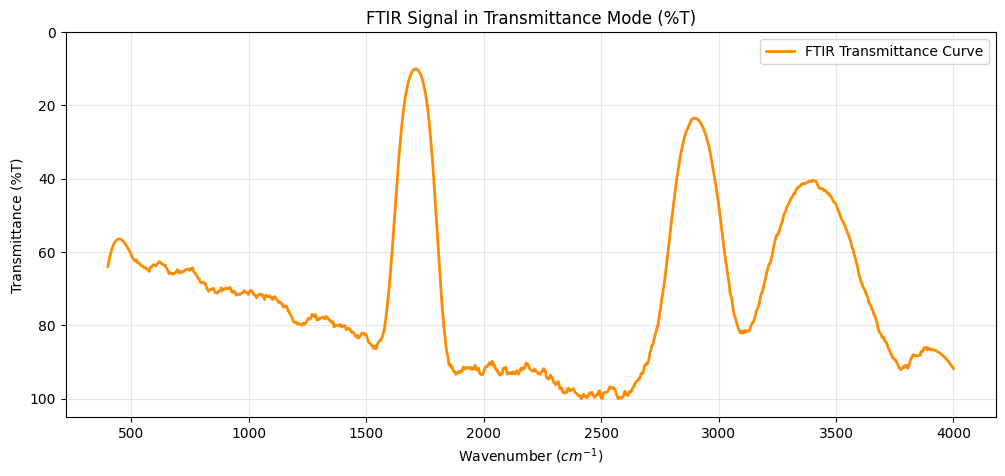

✅ Absorbance converted to Transmittance profile successfully.


In [55]:
# --- Task 4: Converting Absorbance to Transmittance (%T) ---

# Using the exact analytical relationship: %T = 10^(2 - A)
df['Transmittance'] = 10**(2 - df['Final'])

plt.figure(figsize=(12, 5))
plt.plot(df['Wavenumber'], df['Transmittance'], color='darkorange', linewidth=2, label='FTIR Transmittance Curve')
plt.title("FTIR Signal in Transmittance Mode (%T)")
plt.xlabel('Wavenumber ($cm^{-1}$)')
plt.ylabel('Transmittance (%T)')
plt.ylim(0, 105) # Normal limits for clean %T spectral views
plt.gca().invert_yaxis() # Traditional spectroscopy convention: plot with peaks pointing down
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("✅ Absorbance converted to Transmittance profile successfully.")

### Next Step: 
Once you have optimized your parameters, try uploading a raw .csv file from your own research into the Colab "Files" tab and modify the loading script to process your own data!

✅ Custom CSV parsed successfully!


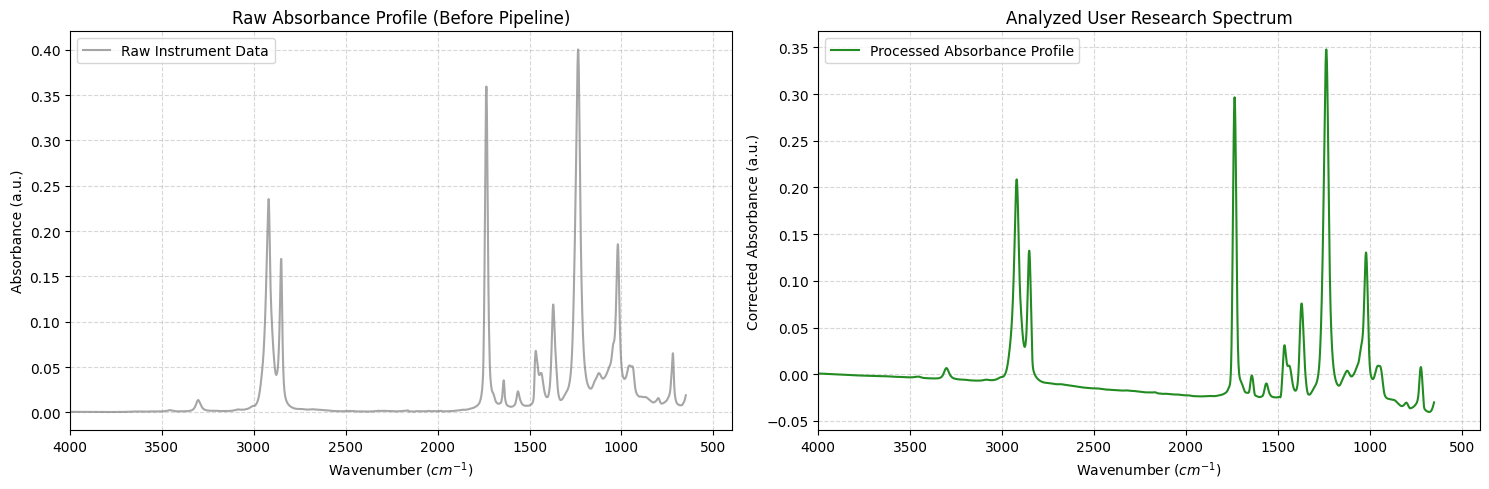

In [56]:
def process_user_micro_csv(filepath):
    """
    Parses a user-supplied lab CSV file starting content extraction on line 2,
    automatically looking for 'cm-1' and '%T' columns to convert to Absorbance.
    """
    if not os.path.exists(filepath):
        print(f"❌ File not found at '{filepath}'. Please upload your file via the side panel.")
        return None
        
    try:
        # skiprows=1 skips line 1, making line 2 the header row.
        user_df = pd.read_csv(filepath, skiprows=1)
        
        # Strip white spaces from columns to ensure consistent lookup
        user_df.columns = user_df.columns.str.strip()
        
        if 'cm-1' not in user_df.columns or '%T' not in user_df.columns:
            print("❌ Parsing Error: Verify that your file has column names labeled exactly 'cm-1' and '%T' on line 2.")
            print(f"Detected columns: {list(user_df.columns)}")
            return None
            
        print("✅ Custom CSV parsed successfully!")
        
        # Clean missing values safely
        user_df['%T'] = user_df['%T'].interpolate(method='linear')
        
        # Calculate raw operational Absorbance from Transmittance: A = 2 - log10(%T)
        # Avoid mathematical domain errors by filtering out values less than or equal to 0
        user_df = user_df[user_df['%T'] > 0].copy()
        user_df['Raw_Absorbance'] = 2 - np.log10(user_df['%T'])
        
        # Process using established Module 2 pipeline parameters
        user_df['Smoothed'] = savgol_filter(user_df['Raw_Absorbance'], window_length=31, polyorder=2)
        
        # Apply low-order baseline correction
        z = np.polyfit(user_df['cm-1'], user_df['Smoothed'], 2)
        p = np.poly1d(z)
        user_df['Clean_Absorbance'] = user_df['Smoothed'] - p(user_df['cm-1'])

        # 1. Calculate Transmittance from the final processed absorbance
        df['Transmittance'] = 10 ** (2 - user_df['Clean_Absorbance'])
        
        # 2. Create side-by-side comparison plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Plot A: The Raw Absorbance Profile (with Noise and Drift)
        ax1.plot(user_df['cm-1'], user_df['Raw_Absorbance'], color='gray', alpha=0.7, label='Raw Instrument Data')
        ax1.title.set_text("Raw Absorbance Profile (Before Pipeline)")
        ax1.set_xlabel("Wavenumber ($cm^{-1}$)")
        ax1.set_ylabel("Absorbance (a.u.)")
        ax1.set_xlim(4000, 400)
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend()

        # Plot B: The Post-Pipeline Absorbance Profile 
        ax2.plot(user_df['cm-1'], user_df['Clean_Absorbance'], color='forestgreen', label='Processed Absorbance Profile')
        ax2.title.set_text("Analyzed User Research Spectrum")
        ax2.set_xlabel("Wavenumber ($cm^{-1}$)")
        ax2.set_ylabel("Corrected Absorbance (a.u.)")
        ax2.set_xlim(4000, 400)
        ax2.grid(True, linestyle='--', alpha=0.5)
        ax2.legend()

        plt.tight_layout()
        plt.show()
        
        return user_df
        
    except Exception as e:
        print(f"❌ Execution failed during analysis: {str(e)}")
        return None

# To execute with real data, uncomment and replace with your local filename:
analyzed_data = process_user_micro_csv('my_raw_ftir_export.csv')

### 🔍 Automatic Peak Detection & Identification
This cell scans your processed research data (`user_df`) to automatically locate and catalog key chemical functional groups based on absorbance maxima.

🔬 DETECTED CHEMICAL BANDS (6 total):
Peak #1: 2921.0 cm⁻¹  (Absorbance: 0.209 a.u.)
Peak #2: 2853.0 cm⁻¹  (Absorbance: 0.132 a.u.)
Peak #3: 1735.0 cm⁻¹  (Absorbance: 0.296 a.u.)
Peak #4: 1371.0 cm⁻¹  (Absorbance: 0.076 a.u.)
Peak #5: 1236.0 cm⁻¹  (Absorbance: 0.348 a.u.)
Peak #6: 1020.0 cm⁻¹  (Absorbance: 0.130 a.u.)



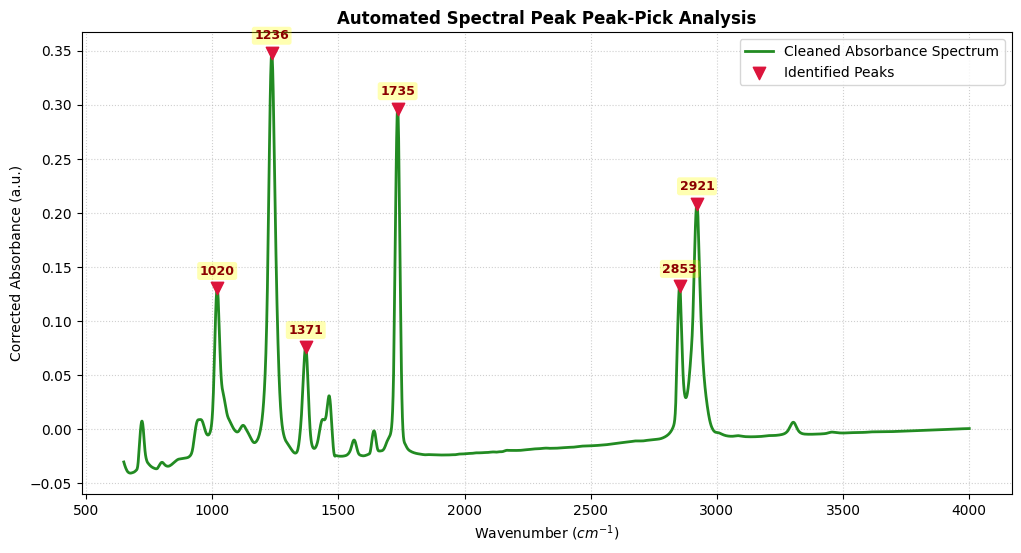

In [64]:
from scipy.signal import find_peaks

# If prominence is too high, the algorithm will miss tiny
# but highly crucial finger-print regions (like weak C-O stretches).
# If it's too low, the algorithm will start labeling random instrument noise ripples as chemical peaks!

def identify_and_plot_peaks(user_df, prominence=0.05, distance=20):
    """
    Finds peaks in the 'Clean_Absorbance' column of user_df, 
    prints their precise wavenumbers, and highlights them on a plot.
    """
    if user_df is None or 'Clean_Absorbance' not in user_df.columns:
        print("❌ Operational Error: Please run the CSV processing cell successfully first.")
        return
    
    # Extract arrays
    wavenumbers = user_df['cm-1'].values
    absorbance = user_df['Clean_Absorbance'].values
    
    # 1. Use SciPy to find peaks based on prominence (height relative to local background)
    # and distance (minimum horizontal pixel separation between peaks)
    peak_indices, properties = find_peaks(absorbance, prominence=prominence, distance=distance)
    
    if len(peak_indices) == 0:
        print("⚠️ No peaks detected. Try lowering the 'prominence' parameter to catch smaller bands.")
        return
        
    # 2. Extract and sort the peak data
    detected_wavenumbers = wavenumbers[peak_indices]
    detected_heights = absorbance[peak_indices]
    
    print("=========================================")
    print(f"🔬 DETECTED CHEMICAL BANDS ({len(peak_indices)} total):")
    print("=========================================")
    for idx, (wn, h) in enumerate(zip(detected_wavenumbers, detected_heights), 1):
        print(f"Peak #{idx}: {wn:.1f} cm⁻¹  (Absorbance: {h:.3f} a.u.)")
    print("=========================================\n")
    
    # 3. Visualization with Annotation Labels
    plt.figure(figsize=(12, 6))
    plt.plot(wavenumbers, absorbance, color='forestgreen', linewidth=2, label='Cleaned Absorbance Spectrum')
    
    # Draw red markers on top of found peaks
    plt.scatter(detected_wavenumbers, detected_heights, color='crimson', marker='v', s=80, zorder=3, label='Identified Peaks')
    
    # Dynamically annotate each peak with its wavenumber value
    for wn, h in zip(detected_wavenumbers, detected_heights):
        plt.annotate(f"{wn:.0f}", 
                     xy=(wn, h), 
                     xytext=(0, 10), # Offset the text slightly above the peak point
                     textcoords='offset points', 
                     ha='center', 
                     fontsize=9, 
                     fontweight='bold',
                     color='darkred',
                     bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3, ec='none'))
                     
    plt.title("Automated Spectral Peak Peak-Pick Analysis", fontsize=12, fontweight='bold')
    plt.xlabel("Wavenumber ($cm^{-1}$)")
    plt.ylabel("Corrected Absorbance (a.u.)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.show()

# To execute with your uploaded data, uncomment this line:
identify_and_plot_peaks(analyzed_data, prominence=0.05)